# Crop Recommendation System - Exploratory Data Analysis (EDA)

## Introduction
This notebook explores a crop dataset to analyze soil nutrients, weather conditions, and crop suitability. The goal is to uncover insights that can help recommend the best crops for specific environmental conditions.

## 1. Imports
The necessary libraries for data manipulation, visualization, and analysis are imported.

In [ ]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Dataset Overview

### 2.1 Read Dataset
The dataset is loaded into a Pandas DataFrame for analysis.

In [3]:
# Load the dataset
df = pd.read_csv('../data/crop_recommendation.csv')

# Display the first few rows of the dataset
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


### 2.2 Dataset Information
Basic information about the dataset, such as column names, data types, and missing values, is displayed.

In [4]:
# Display dataset information
df.info()

# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB
Missing values per column:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64


## 3. Data Cleaning

### 3.1 Check for Duplicates
Remove duplicate rows if they exist.

In [5]:
# Check for duplicate rows
print(f"Number of duplicate rows: {df.duplicated().sum()}")

# Drop duplicates if any
df = df.drop_duplicates()

Number of duplicate rows: 0


### 3.2 Data Type Corrections
Ensure all columns have the correct data types.

In [6]:
# Check data types
print("Data types of columns:")
print(df.dtypes)

Data types of columns:
N                int64
P                int64
K                int64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
label           object
dtype: object


## 4. Exploratory Data Analysis (EDA)

### 4.1 Summary Statistics
Generate summary statistics for numeric columns to understand the data distribution.

In [9]:
# Summary statistics for numeric columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
N,2200.0,50.551818,36.917334,0.000000,21.000000,37.000000,84.250000,140.000000
P,2200.0,53.362727,32.985883,5.000000,28.000000,51.000000,68.000000,145.000000
K,2200.0,48.149091,50.647931,5.000000,20.000000,32.000000,49.000000,205.000000
temperature,2200.0,25.616244,5.063749,8.825675,22.769375,25.598693,28.561654,43.675493
humidity,2200.0,71.481779,22.263812,14.258040,60.261953,80.473146,89.948771,99.981876
ph,2200.0,6.469480,0.773938,3.504752,5.971693,6.425045,6.923643,9.935091
rainfall,2200.0,103.463655,54.958389,20.211267,64.551686,94.867624,124.267508,298.560117


### 4.2 Correlation Analysis
Analyze relationships between numeric features using a correlation heatmap.

Text(0.5, 1.0, 'Correlation Heatmap')

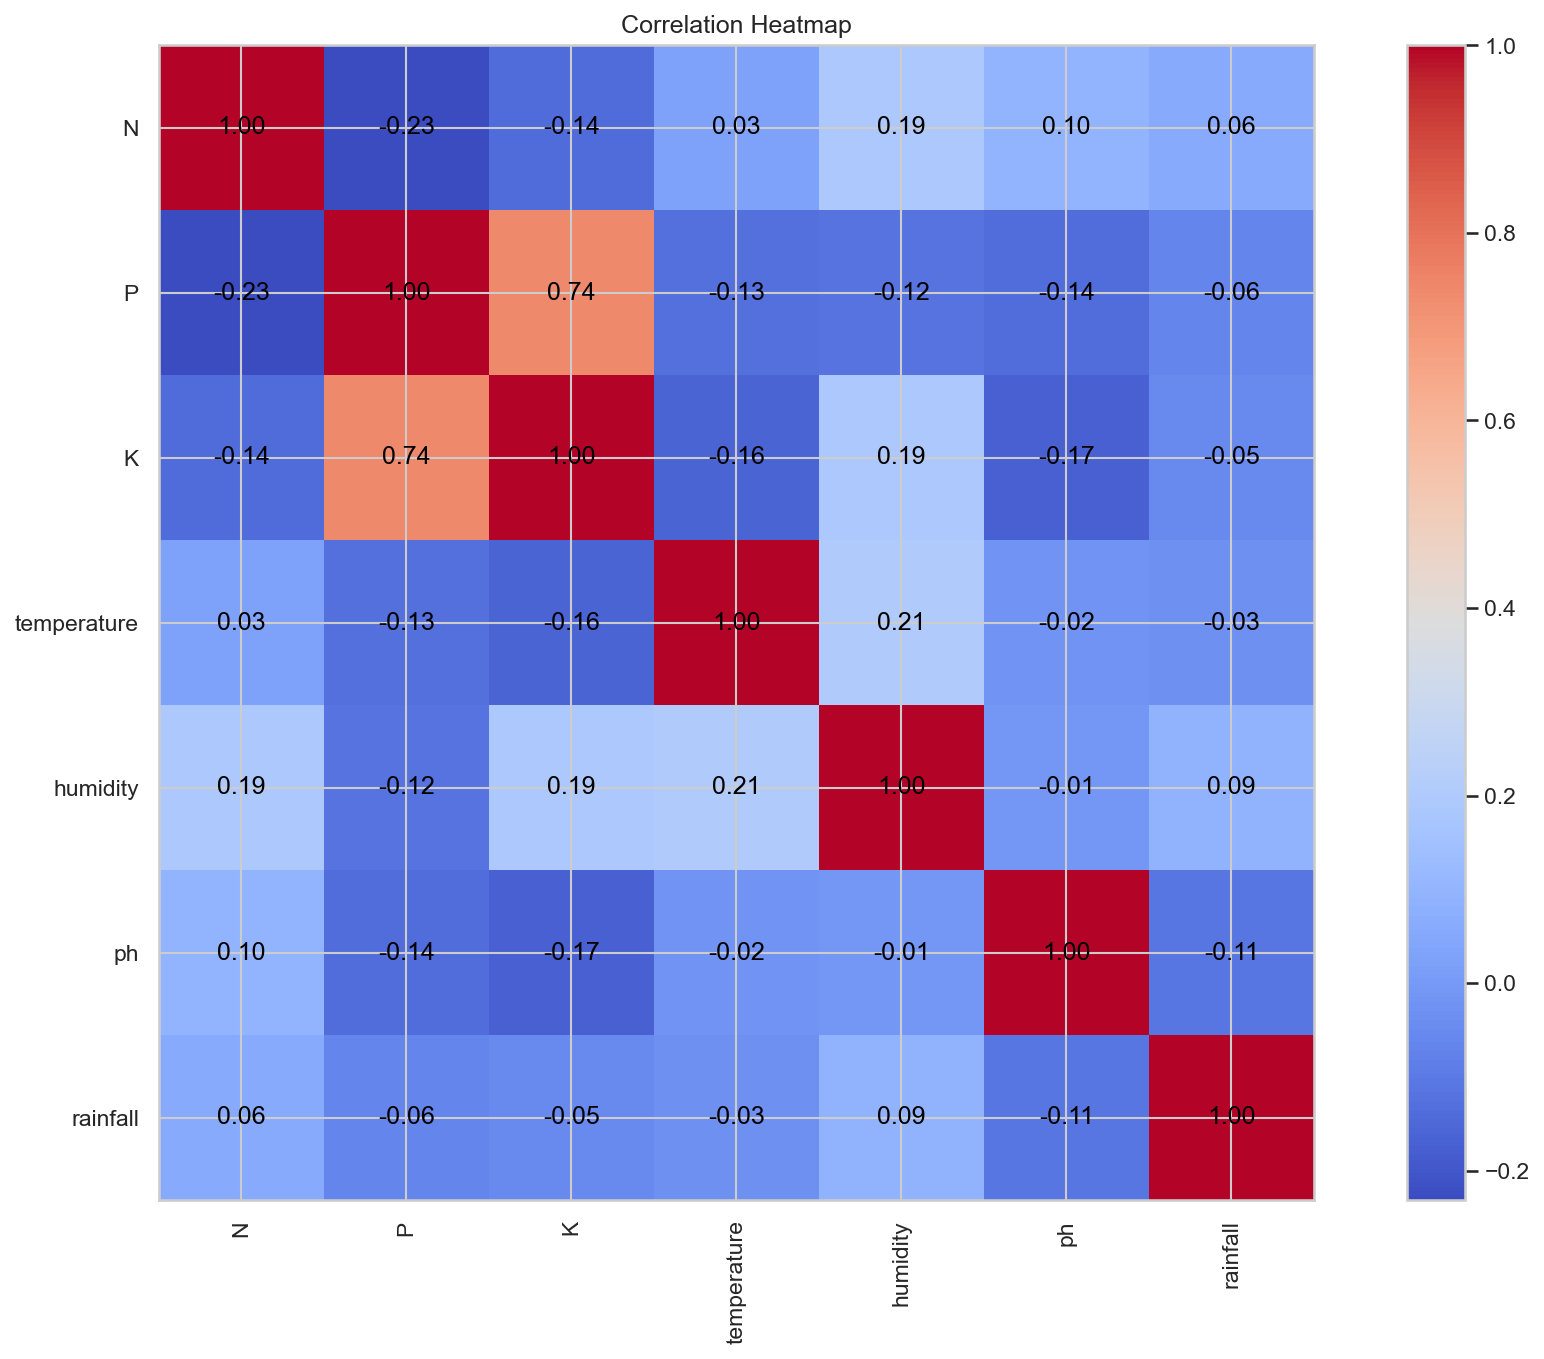

In [23]:
numeric_df = df.select_dtypes(include=['number'])
corr_matrix = numeric_df.corr()

# Create a heatmap using Matplotlib
plt.figure(figsize=(16, 10), dpi=150)
plt.imshow(corr_matrix, cmap='coolwarm', interpolation='none', aspect='equal')
plt.colorbar()  # Add a color bar to indicate correlation values

# Add labels for rows and columns
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

# Add correlation values to the heatmap
for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        plt.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha='center', va='center', color='black')

plt.title('Correlation Heatmap')

### 4.3 Nutrient Distribution
Visualize the distribution of soil nutrients (Nitrogen, Phosphorus, Potassium) for different crops.

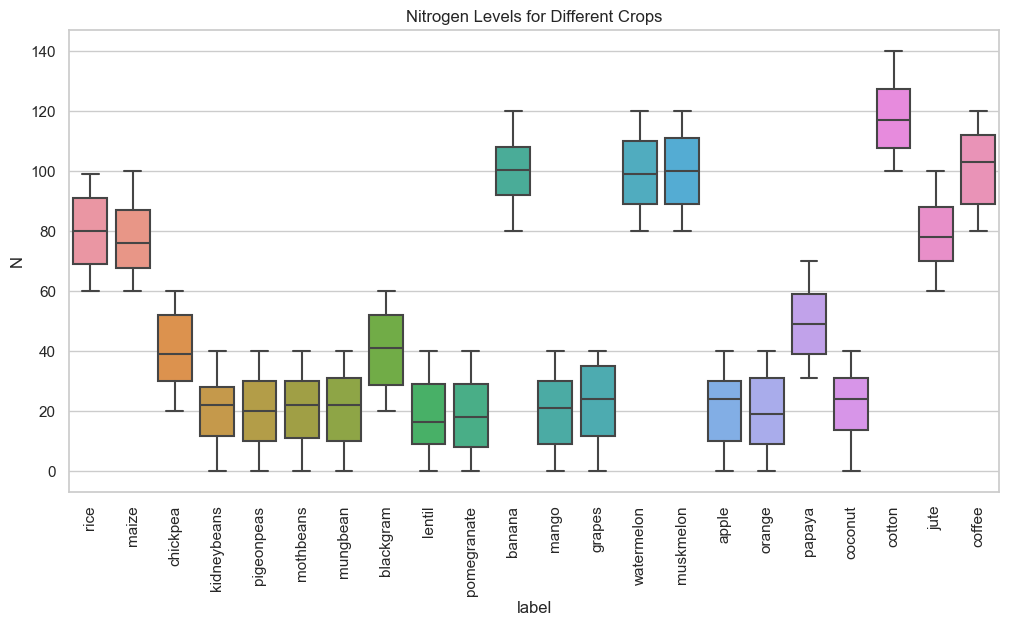

In [24]:
# Boxplot for Nitrogen levels
plt.figure(figsize=(12, 6))
sns.boxplot(x='label', y='N', data=df)
plt.title('Nitrogen Levels for Different Crops')
plt.xticks(rotation=90)
plt.show()

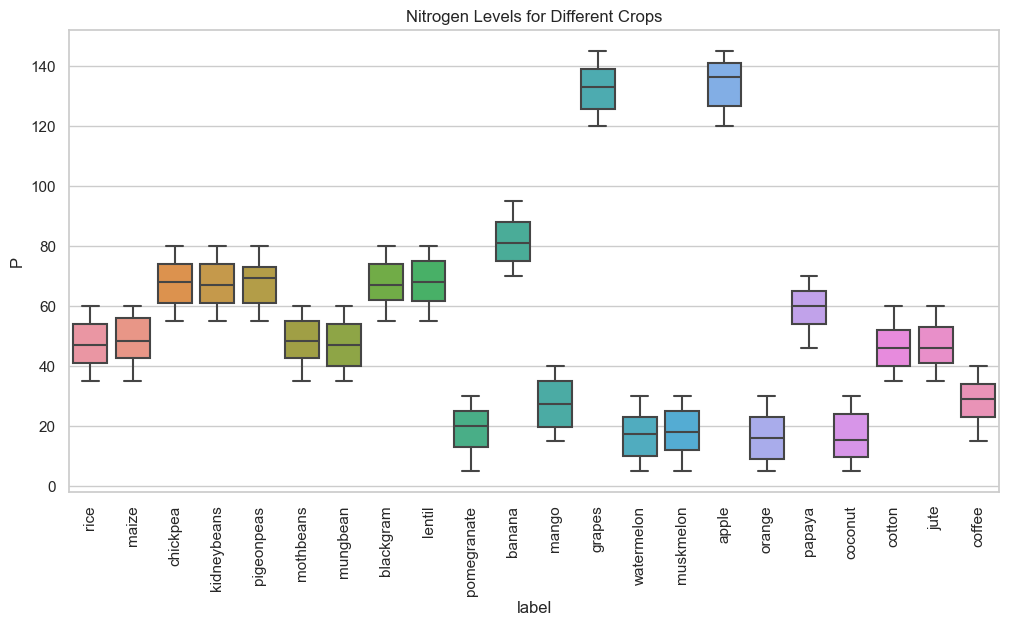

In [25]:
# Boxplot for Nitrogen levels
plt.figure(figsize=(12, 6))
sns.boxplot(x='label', y='P', data=df)
plt.title('Nitrogen Levels for Different Crops')
plt.xticks(rotation=90)
plt.show()

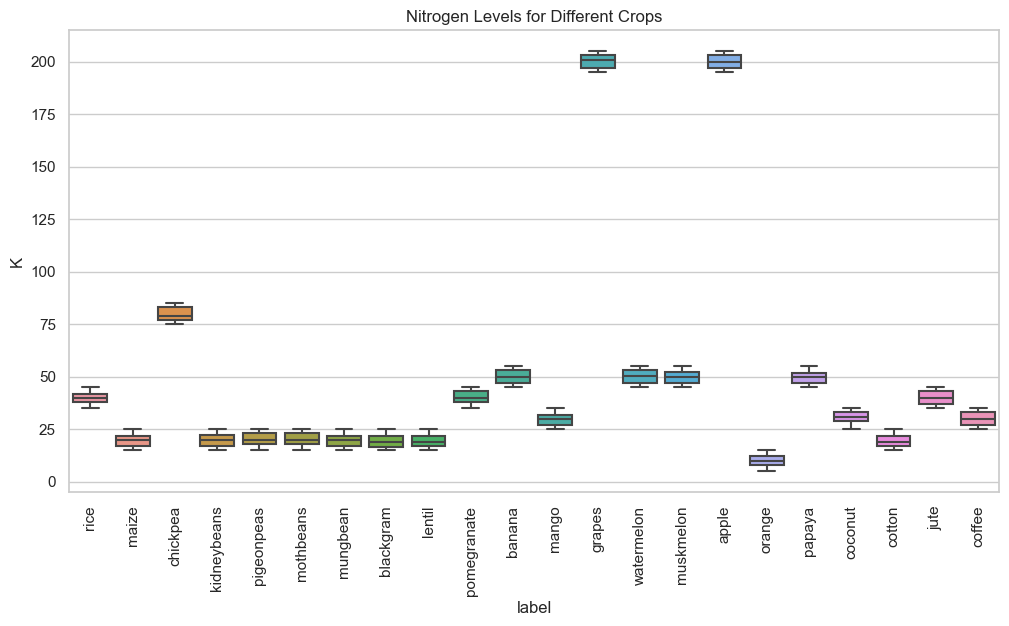

In [26]:
# Boxplot for Nitrogen levels
plt.figure(figsize=(12, 6))
sns.boxplot(x='label', y='K', data=df)
plt.title('Nitrogen Levels for Different Crops')
plt.xticks(rotation=90)
plt.show()

### 4.4 Crop Frequency Distribution
Analyze the frequency of different crops in the dataset.

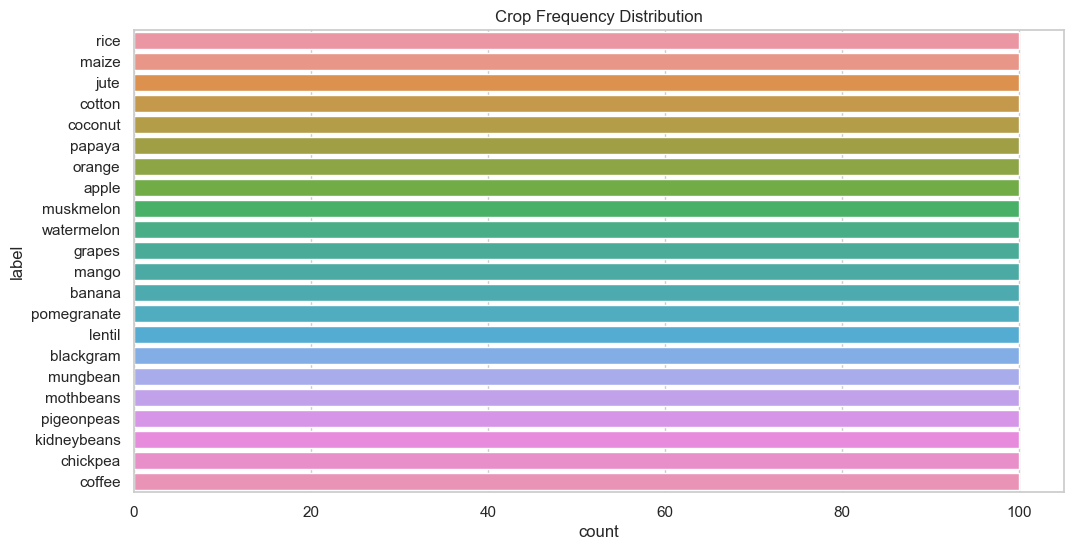

In [27]:
# Countplot for crop frequency
plt.figure(figsize=(12, 6))
sns.countplot(y=df['label'], order=df['label'].value_counts().index)
plt.title('Crop Frequency Distribution')
plt.show()

### 4.5 Temperature and Rainfall Analysis
Explore how temperature and rainfall vary across different crops.

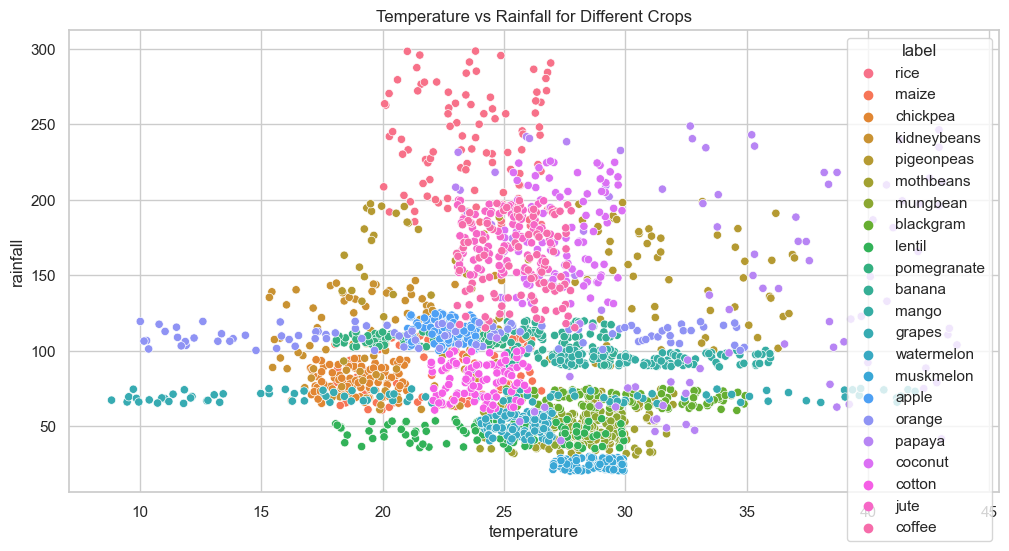

In [28]:
# Scatterplot for temperature vs rainfall
plt.figure(figsize=(12, 6))
sns.scatterplot(x='temperature', y='rainfall', hue='label', data=df)
plt.title('Temperature vs Rainfall for Different Crops')
plt.show()

array([[<Axes: title={'center': 'N'}>, <Axes: title={'center': 'P'}>,
        <Axes: title={'center': 'K'}>],
       [<Axes: title={'center': 'temperature'}>,
        <Axes: title={'center': 'humidity'}>,
        <Axes: title={'center': 'ph'}>],
       [<Axes: title={'center': 'rainfall'}>, <Axes: >, <Axes: >]],
      dtype=object)

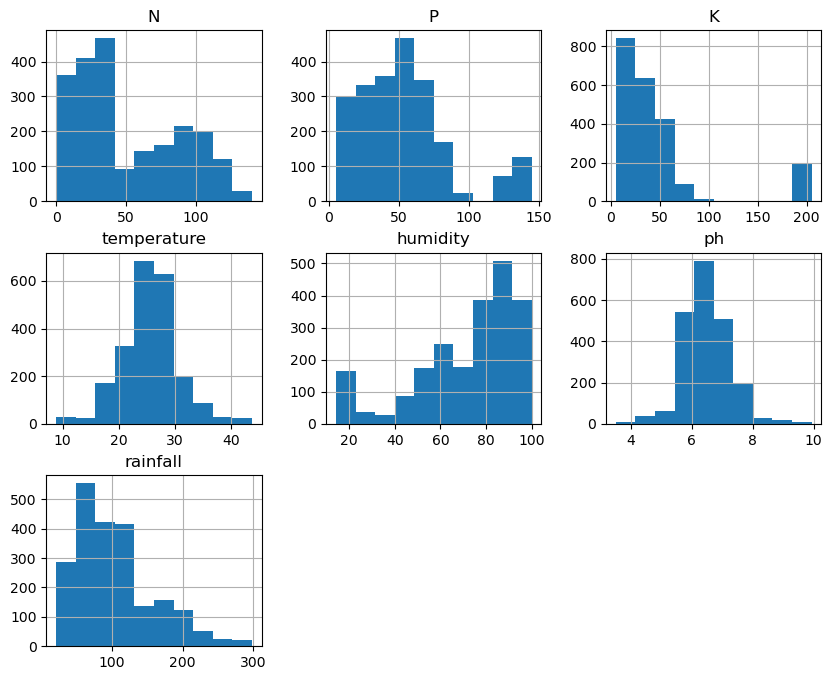

In [17]:
df.hist(figsize=(10, 8))

## 5. Insights and Observations

### Key Insights:
- Crops like rice require higher nitrogen levels compared to wheat.
- Temperature and rainfall are critical factors for crop growth.


## 6. Conclusions

This analysis provides insights into the relationships between soil nutrients, weather conditions, and crop types. These findings can be used to build a crop recommendation system or guide agricultural practices.